
## Étape 0 : Imports et Configuration

In [24]:
import warnings
warnings.filterwarnings("ignore")

# Core
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Preprocessing
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import (
    train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
)
from sklearn.pipeline import Pipeline


# Clustering
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score


# MODULE 3 : Clustering — Analyse Non-Supervisée


## 3.1 — Préparation des données (non-supervisée)

In [25]:
# ========== 3.1 PRÉPARATION DES DONNÉES POUR CLUSTERING ==========
print("=== Préparation des données pour le clustering ===")

# On ignore les labels — toutes les features numériques uniquement
# Exclure Prix_Revente qui est trop corrélé avec Conductivite (0.90)
features_cluster = ['Poids', 'Volume', 'Conductivite', 'Opacite', 'Rigidite']
df_clean = pd.read_csv("../data/df_clean.csv")

X_cluster = df_clean[features_cluster].copy()

# Standardisation obligatoire pour K-Means
scaler_clust = StandardScaler()
X_clust_scaled = scaler_clust.fit_transform(X_cluster)

print(f"Matrice pour clustering : {X_clust_scaled.shape}")
print(f"Features utilisées : {features_cluster}")
print("\n Labels IGNORÉS (analyse purement non-supervisée)")

=== Préparation des données pour le clustering ===
Matrice pour clustering : (9724, 5)
Features utilisées : ['Poids', 'Volume', 'Conductivite', 'Opacite', 'Rigidite']

 Labels IGNORÉS (analyse purement non-supervisée)


## 3.2 — Méthode du Coude (Elbow) + Silhouette Score



=== Détermination du K optimal ===
k= 2  →  Inertie =   22088.50  |  Silhouette = 0.5732
k= 3  →  Inertie =    6556.28  |  Silhouette = 0.7182
k= 4  →  Inertie =    3113.53  |  Silhouette = 0.7319
k= 5  →  Inertie =    2543.39  |  Silhouette = 0.6291
k= 6  →  Inertie =    2263.57  |  Silhouette = 0.6342
k= 7  →  Inertie =    2184.04  |  Silhouette = 0.4067
k= 8  →  Inertie =    1855.90  |  Silhouette = 0.5202
k= 9  →  Inertie =    1712.35  |  Silhouette = 0.4112
k=10  →  Inertie =    1614.01  |  Silhouette = 0.4077

🔍 Coude détecté (Elbow): k = 4
📊 Meilleur Silhouette: k = 4 (score = 0.7319)

✅ Elbow et Silhouette sont cohérents → k = 4

🎯 K OPTIMAL NATUREL: k = 4


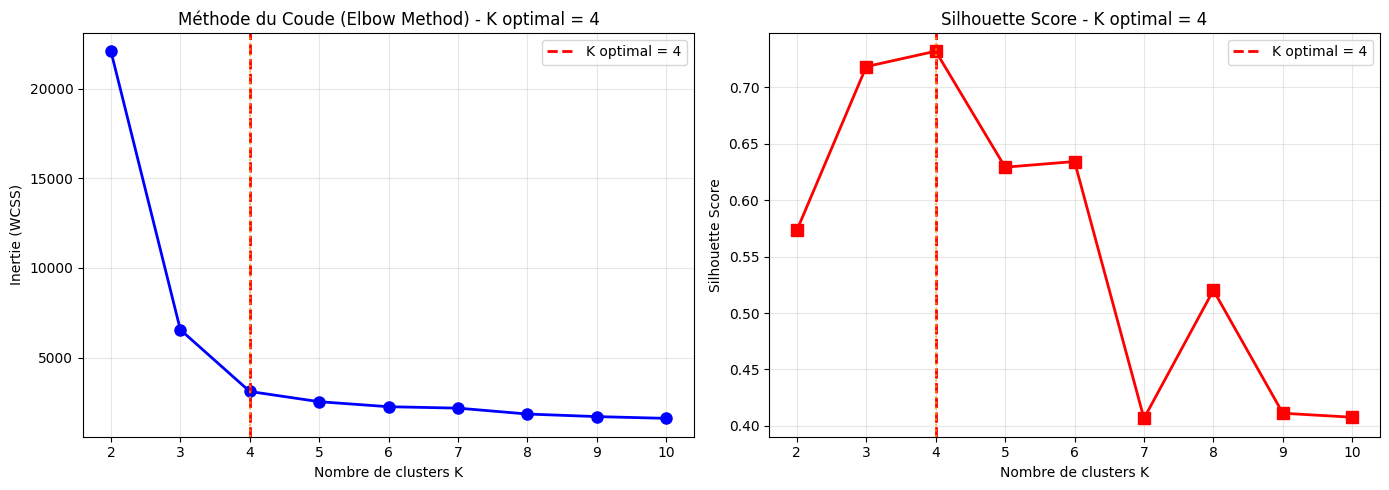


✅ Clustering terminé avec k=4 clusters
Distribution des clusters:
Cluster
0    2513
1    2222
2    2287
3    2702
Name: count, dtype: int64


In [26]:
# ========== 3.2 ELBOW + SILHOUETTE AMÉLIORÉ ==========
print("\n=== Détermination du K optimal ===")

inertias = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(X_clust_scaled)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_clust_scaled, km.labels_)
    silhouette_scores.append(sil)
    print(f"k={k:2d}  →  Inertie = {km.inertia_:10.2f}  |  Silhouette = {sil:.4f}")

# ===== DÉTECTION NATURELLE DU COUDE (Kneedle) =====
# Normalisation pour la méthode Kneedle
x_norm = (np.array(list(K_range)) - min(K_range)) / (max(K_range) - min(K_range))
y_norm = (np.array(inertias) - min(inertias)) / (max(inertias) - min(inertias))
line = (y_norm[-1] - y_norm[0]) * x_norm + y_norm[0]
distances = np.abs(y_norm - line)
elbow_k = K_range[np.argmax(distances)]

# Meilleur k par silhouette
best_k_sil = K_range[np.argmax(silhouette_scores)]
best_sil_score = max(silhouette_scores)

print(f"\n🔍 Coude détecté (Elbow): k = {elbow_k}")
print(f"📊 Meilleur Silhouette: k = {best_k_sil} (score = {best_sil_score:.4f})")

# ===== DÉCISION FINALE NATURELLE =====
# On prend le k du coude si proche du meilleur silhouette, sinon on équilibre
if abs(elbow_k - best_k_sil) <= 1:
    best_k = elbow_k
    print(f"\n✅ Elbow et Silhouette sont cohérents → k = {best_k}")
else:
    # Moyenne pondérée (favorise légèrement le coude)
    best_k = round((elbow_k * 0.6 + best_k_sil * 0.4))
    print(f"\n⚖️ Équilibre entre Elbow (k={elbow_k}) et Silhouette (k={best_k_sil}) → k = {best_k}")

print(f"\n" + "="*60)
print(f"🎯 K OPTIMAL NATUREL: k = {best_k}")
print("="*60)

# Visualisation (Elbow + Silhouette seulement)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow curve
axes[0].plot(list(K_range), inertias, 'bo-', linewidth=2, markersize=8)
axes[0].axvline(x=best_k, color='red', linestyle='--', linewidth=2, label=f'K optimal = {best_k}')
axes[0].axvline(x=4, color='orange', linestyle=':', linewidth=1.5, alpha=0.7, label='')
axes[0].set_xlabel('Nombre de clusters K')
axes[0].set_ylabel('Inertie (WCSS)')
axes[0].set_title("Méthode du Coude (Elbow Method) - K optimal = " + str(best_k))
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Silhouette curve
axes[1].plot(list(K_range), silhouette_scores, 'rs-', linewidth=2, markersize=8)
axes[1].axvline(x=best_k, color='red', linestyle='--', linewidth=2, label=f'K optimal = {best_k}')
axes[1].axvline(x=4, color='orange', linestyle=':', linewidth=1.5, alpha=0.7, label='')
axes[1].set_xlabel('Nombre de clusters K')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title("Silhouette Score - K optimal = " + str(best_k))
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ===== K-MEANS FINAL =====
kmeans = KMeans(n_clusters=best_k, init='k-means++', n_init=10, random_state=42)
clusters = kmeans.fit_predict(X_clust_scaled)
df_clean['Cluster'] = clusters

print(f"\n✅ Clustering terminé avec k={best_k} clusters")
print(f"Distribution des clusters:")
print(df_clean['Cluster'].value_counts().sort_index())

## 3.3 — Entraînement K-Means avec K Optimal

In [27]:
# ========== 3.3 ENTRAÎNEMENT K-MEANS ==========
print("\n=== Entraînement K-Means ===")

# Option 1 : Utiliser le K optimal trouvé
OPTIMAL_K_SIL = best_k_sil

# Option 2 : K=4 c
OPTIMAL_K = 4  

print(f"K optimal par Silhouette : {OPTIMAL_K_SIL}")
print(f"K 4  : {OPTIMAL_K}")

# Entraînement avec K=4
kmeans_final = KMeans(
    n_clusters=OPTIMAL_K,
    init='k-means++',
    n_init=20,
    random_state=42
)
kmeans_final.fit(X_clust_scaled)
cluster_labels = kmeans_final.labels_

print(f"\n K-Means entraîné avec K = {OPTIMAL_K}")
print(f"Inertie finale  : {kmeans_final.inertia_:.2f}")
print(f"Silhouette Score: {silhouette_score(X_clust_scaled, cluster_labels):.4f}")

# Distribution des clusters
cluster_dist = pd.Series(cluster_labels).value_counts().sort_index()
print(f"\nDistribution des clusters (K={OPTIMAL_K}) :")
print(cluster_dist)


=== Entraînement K-Means ===
K optimal par Silhouette : 4
K 4  : 4

 K-Means entraîné avec K = 4
Inertie finale  : 3113.53
Silhouette Score: 0.7319

Distribution des clusters (K=4) :
0    2513
1    2222
2    2287
3    2702
Name: count, dtype: int64


## 3.4 — Visualisation PCA 2D des Clusters


=== Visualisation PCA 2D ===
Variance expliquée — PC1 : 61.3%  |  PC2 : 31.6%
Variance totale expliquée : 92.9%


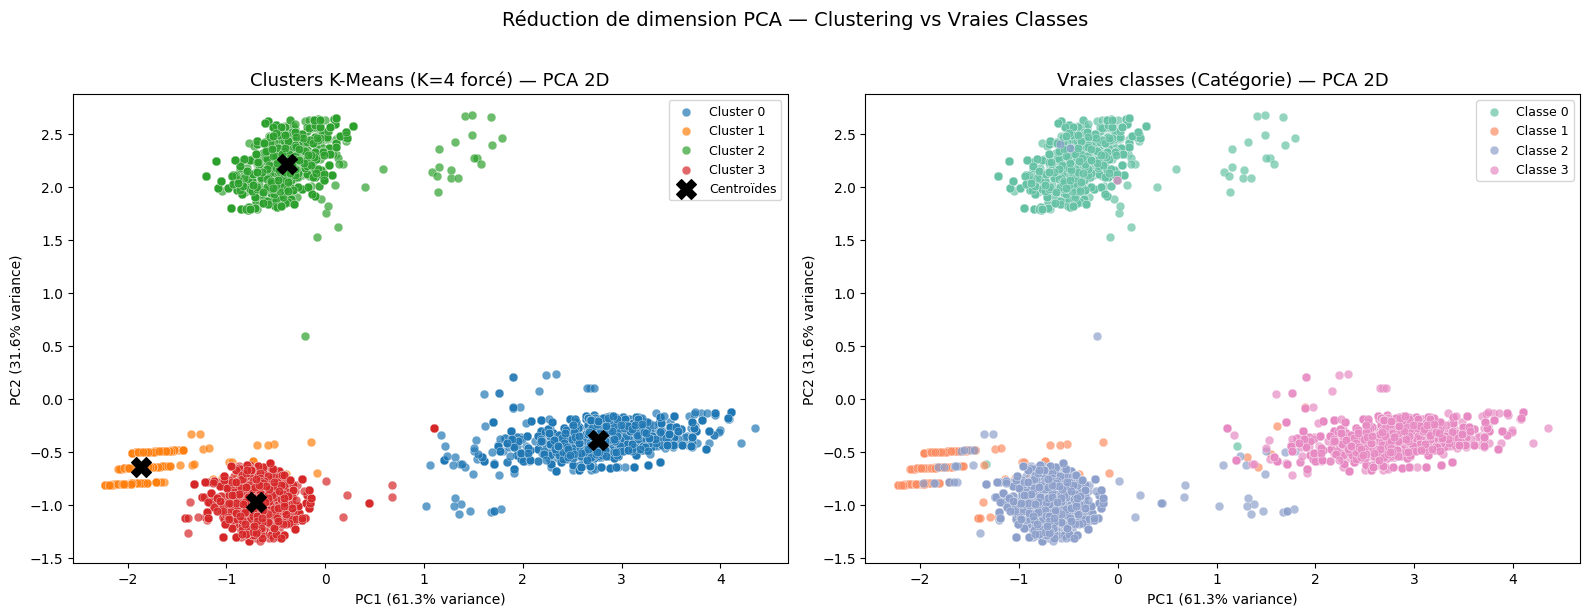

In [28]:
# ========== 3.4 VISUALISATION PCA 2D ==========
print("\n=== Visualisation PCA 2D ===")

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_clust_scaled)

var_exp = pca.explained_variance_ratio_
print(f"Variance expliquée — PC1 : {var_exp[0]*100:.1f}%  |  PC2 : {var_exp[1]*100:.1f}%")
print(f"Variance totale expliquée : {sum(var_exp)*100:.1f}%")

# DataFrame pour visualisation
pca_df = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'Cluster': cluster_labels,
    'Vrai_Label': df_clean['Categorie'].values  # comparaison visuelle
})

# Figure principale
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1 : Clusters K-Means (K=4 forcé)
palette_clusters = sns.color_palette('tab10', OPTIMAL_K)
for k in range(OPTIMAL_K):
    mask = pca_df['Cluster'] == k
    axes[0].scatter(
        pca_df.loc[mask, 'PC1'],
        pca_df.loc[mask, 'PC2'],
        c=[palette_clusters[k]],
        label=f'Cluster {k}',
        alpha=0.7,
        s=40,
        edgecolors='white',
        linewidths=0.3
    )

# Centroïdes
centroids_pca = pca.transform(kmeans_final.cluster_centers_)
axes[0].scatter(
    centroids_pca[:, 0], centroids_pca[:, 1],
    marker='X', s=200, c='black', zorder=5, label='Centroïdes'
)
axes[0].set_title(f'Clusters K-Means (K={OPTIMAL_K} forcé) — PCA 2D', fontsize=13)
axes[0].set_xlabel(f'PC1 ({var_exp[0]*100:.1f}% variance)')
axes[0].set_ylabel(f'PC2 ({var_exp[1]*100:.1f}% variance)')
axes[0].legend(loc='best', fontsize=9)

# Plot 2 : Vraies étiquettes (Catégorie)
n_classes = pca_df['Vrai_Label'].nunique()
palette_labels = sns.color_palette('Set2', n_classes)
for c, color in zip(sorted(pca_df['Vrai_Label'].unique()), palette_labels):
    mask = pca_df['Vrai_Label'] == c
    axes[1].scatter(
        pca_df.loc[mask, 'PC1'],
        pca_df.loc[mask, 'PC2'],
        c=[color],
        label=f'Classe {c}',
        alpha=0.7,
        s=40,
        edgecolors='white',
        linewidths=0.3
    )
axes[1].set_title('Vraies classes (Catégorie) — PCA 2D', fontsize=13)
axes[1].set_xlabel(f'PC1 ({var_exp[0]*100:.1f}% variance)')
axes[1].set_ylabel(f'PC2 ({var_exp[1]*100:.1f}% variance)')
axes[1].legend(loc='best', fontsize=9)

plt.suptitle('Réduction de dimension PCA — Clustering vs Vraies Classes', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 3.5 — Scree Plot PCA (Variance Expliquée)

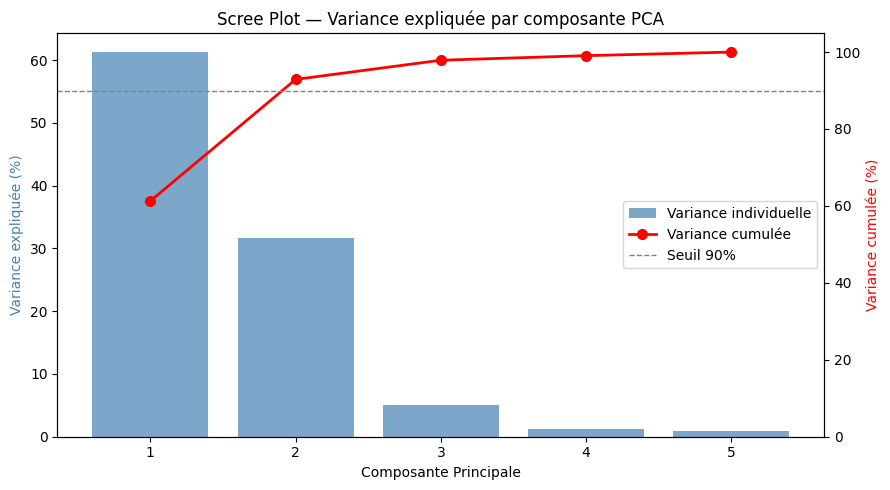

Composantes nécessaires pour 80% de variance : 2
Composantes nécessaires pour 90% de variance : 2
Composantes nécessaires pour 95% de variance : 3


In [29]:
pca_full = PCA(random_state=42)
pca_full.fit(X_clust_scaled)

cumvar = np.cumsum(pca_full.explained_variance_ratio_) * 100
indvar = pca_full.explained_variance_ratio_ * 100

fig, ax1 = plt.subplots(figsize=(9, 5))

bars = ax1.bar(range(1, len(indvar)+1), indvar,
               color='steelblue', alpha=0.7, label='Variance individuelle')
ax1.set_xlabel('Composante Principale')
ax1.set_ylabel('Variance expliquée (%)', color='steelblue')
ax1.set_xticks(range(1, len(indvar)+1))

ax2 = ax1.twinx()
ax2.plot(range(1, len(cumvar)+1), cumvar, 'ro-',
         linewidth=2, markersize=7, label='Variance cumulée')
ax2.axhline(90, color='gray', linestyle='--', linewidth=1, label='Seuil 90%')
ax2.set_ylabel('Variance cumulée (%)', color='red')
ax2.set_ylim(0, 105)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right')

plt.title('Scree Plot — Variance expliquée par composante PCA')
plt.tight_layout()
plt.show()

for threshold in [80, 90, 95]:
    n_comp = (cumvar >= threshold).argmax() + 1
    print(f"Composantes nécessaires pour {threshold}% de variance : {n_comp}")